In [1]:
 .......import pandas as pd

data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes","Yes","Yes","Yes","No"]
}

df = pd.DataFrame(data)

df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [2]:
import numpy as np

def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    entropy = 0
    for count in counts:
        p = count / sum(counts)
        entropy -= p * np.log2(p)
    return entropy

In [3]:
entropy(df["PlayTennis"])

np.float64(0.9402859586706311)

In [4]:
def information_gain(data, feature, target="PlayTennis"):
    total_entropy = entropy(data[target])

    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[feature] == values[i]]
        weighted_entropy += (counts[i] / sum(counts)) * entropy(subset[target])

    gain = total_entropy - weighted_entropy
    return gain

In [5]:
for column in df.columns[:-1]:
    print(column, information_gain(df, column))

Outlook 0.24674981977443933
Temperature 0.02922256565895487
Humidity 0.15183550136234159
Wind 0.04812703040826949


In [6]:
def id3(data, features, target="PlayTennis"):

    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]

    if len(features) == 0:
        return data[target].mode()[0]

    gains = [information_gain(data, feature, target) for feature in features]
    best_feature = features[np.argmax(gains)]

    tree = {best_feature:{}}

    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]
        remaining_features = [f for f in features if f != best_feature]
        subtree = id3(subset, remaining_features, target)
        tree[best_feature][value] = subtree

    return tree

In [7]:
features = df.columns[:-1]

tree = id3(df, features)

tree

{'Outlook': {'Overcast': 'Yes',
  'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
  'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}

In [8]:
!pip install graphviz

In [9]:
from graphviz import Digraph

In [14]:
def draw_tree(tree, graph=None, parent=None):

    if graph is None:
        graph = Digraph()

    if isinstance(tree, dict):
        root = list(tree.keys())[0]

        for value, subtree in tree[root].items():
            node_name = f"{root}={value}"
            graph.node(node_name)

            if parent:
                graph.edge(parent, node_name)

            draw_tree(subtree, graph, node_name)

    else:
        graph.node(str(tree))
        if parent:
            graph.edge(parent, str(tree))

    return graph

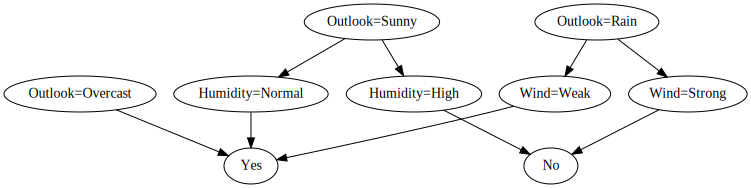

In [15]:
graph = draw_tree(tree)
graph